# Data Augmentation Strategies

This notebook documents the class imbalance problem and explores augmentation strategies for training.

The ISIC 2019 dataset has a 53.87:1 imbalance ratio between the majority class (NV) and minority class (DF). Without proper handling, models will be biased toward predicting the majority class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import json
from collections import Counter

In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "classification"
RESULTS_DIR = PROJECT_ROOT / "results"

In [3]:
# Load split data
df_train = pd.read_csv(DATA_DIR / "train_split.csv")
print(f"Training samples: {len(df_train)}")

Training samples: 7010


## 1. Class Imbalance Analysis

In [4]:
class_counts = df_train["class_label"].value_counts().sort_values(ascending=False)
print("Training Set Class Distribution:")
print(class_counts)

Training Set Class Distribution:
class_label
NV       4693
MEL       779
BKL       769
BCC       360
AKIEC     229
VASC       99
DF         81
Name: count, dtype: int64


In [5]:
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nMajority class: {majority_class} ({class_counts.max()} samples)")
print(f"Minority class: {minority_class} ({class_counts.min()} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")


Majority class: NV (4693 samples)
Minority class: DF (81 samples)
Imbalance ratio: 57.94:1


In [6]:
# Calculate samples needed to balance
target_count = class_counts.max()
samples_needed = {cls: target_count - count for cls, count in class_counts.items()}

print("\nSamples needed to balance each class:")
for cls, needed in samples_needed.items():
    print(f"  {cls}: +{needed}")


Samples needed to balance each class:
  NV: +0
  MEL: +3914
  BKL: +3924
  BCC: +4333
  AKIEC: +4464
  VASC: +4594
  DF: +4612


In [7]:
total_synthetic_needed = sum(samples_needed.values())
print(f"\nTotal synthetic samples needed for balance: {total_synthetic_needed}")


Total synthetic samples needed for balance: 25841


The severe imbalance means minority classes like DF (239 → 9012 needed) and VASC (253 → 8759 needed) would require ~37x synthetic augmentation to match NV. This is impractical with simple augmentation alone.

## 2. Augmentation Techniques

- Rotation (dermoscopes have no fixed orientation)
- Horizontal/Vertical flip (lesions have no canonical orientation)
- Zoom/Scale (lesions vary in size relative to image frame)
- Brightness/Contrast (lighting varies between acquisitions)

In [8]:
def rotate_image(image, angle):
    """Rotate image by specified angle."""
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)

In [9]:
def flip_image(image, direction):
    """Flip image horizontally (1) or vertically (0)."""
    return cv2.flip(image, direction)

In [10]:
def zoom_image(image, zoom_factor):
    """Zoom into center of image."""
    h, w = image.shape[:2]
    
    # Calculate crop region
    new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
    start_h, start_w = (h - new_h) // 2, (w - new_w) // 2
    
    # Crop and resize back
    cropped = image[start_h:start_h+new_h, start_w:start_w+new_w]
    return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

In [11]:
def adjust_brightness(image, factor):
    """Adjust brightness. Factor > 1 brightens, < 1 darkens."""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv = hsv.astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    hsv = hsv.astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

In [12]:
# Load a sample image for demonstration
sample_img_name = df_train.iloc[0]["image"]
sample_path = PROCESSED_DIR / f"{sample_img_name}.jpg"
sample_img = cv2.imread(str(sample_path))

In [13]:
# Generate augmented versions
augmentations = [
    ("Original", sample_img),
    ("Rotate 90", rotate_image(sample_img, 90)),
    ("Rotate 180", rotate_image(sample_img, 180)),
    ("Rotate 270", rotate_image(sample_img, 270)),
    ("H-Flip", flip_image(sample_img, 1)),
    ("V-Flip", flip_image(sample_img, 0)),
    ("Zoom 1.2x", zoom_image(sample_img, 1.2)),
    ("Brighter", adjust_brightness(sample_img, 1.3)),
    ("Darker", adjust_brightness(sample_img, 0.7)),
]

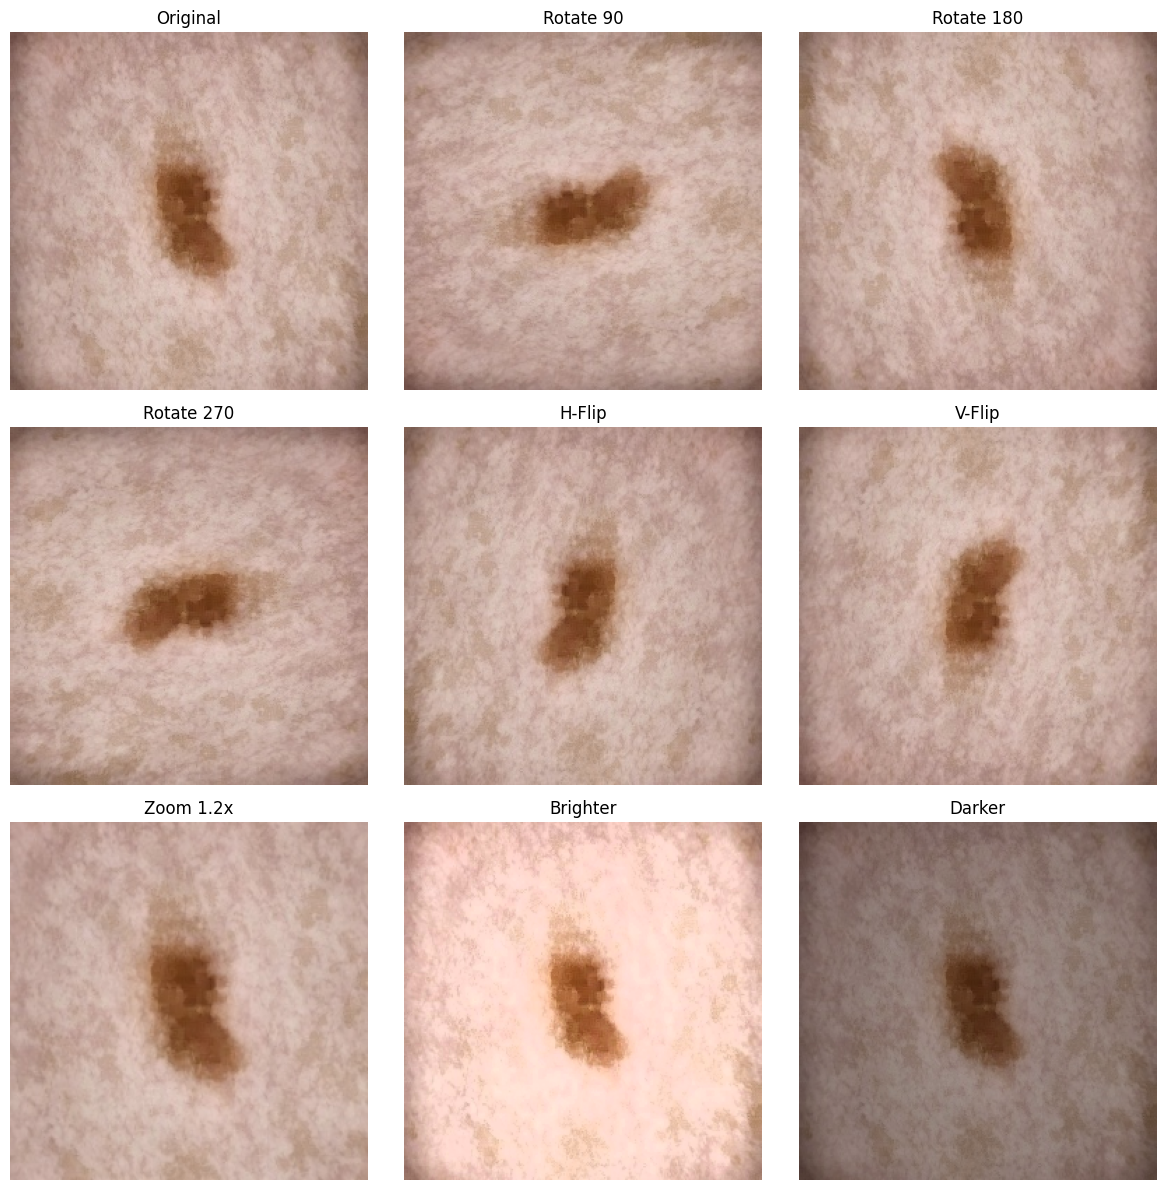

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, (title, img) in enumerate(augmentations):
    axes[idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(title)
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Balancing Strategy 1: Class Weights

Class weights adjust the loss function to penalize misclassification of minority classes more heavily.

Formula: weight(class) = total_samples / (num_classes × class_samples)

In [15]:
def compute_class_weights(class_counts):
    """Compute balanced class weights."""
    total = sum(class_counts.values())
    n_classes = len(class_counts)
    weights = {}
    for cls, count in class_counts.items():
        weights[cls] = total / (n_classes * count)
    return weights

In [16]:
class_weights = compute_class_weights(dict(class_counts))

print("Computed Class Weights:")
for cls in class_counts.index:
    print(f"  {cls}: {class_weights[cls]:.4f}")

Computed Class Weights:
  NV: 0.2134
  MEL: 1.2855
  BKL: 1.3022
  BCC: 2.7817
  AKIEC: 4.3731
  VASC: 10.1154
  DF: 12.3633


Class weights scale the loss contribution: DF (weight ~9.3) has 9.3x the loss contribution per sample compared to NV (weight ~0.17). This encourages the model to learn minority class features.

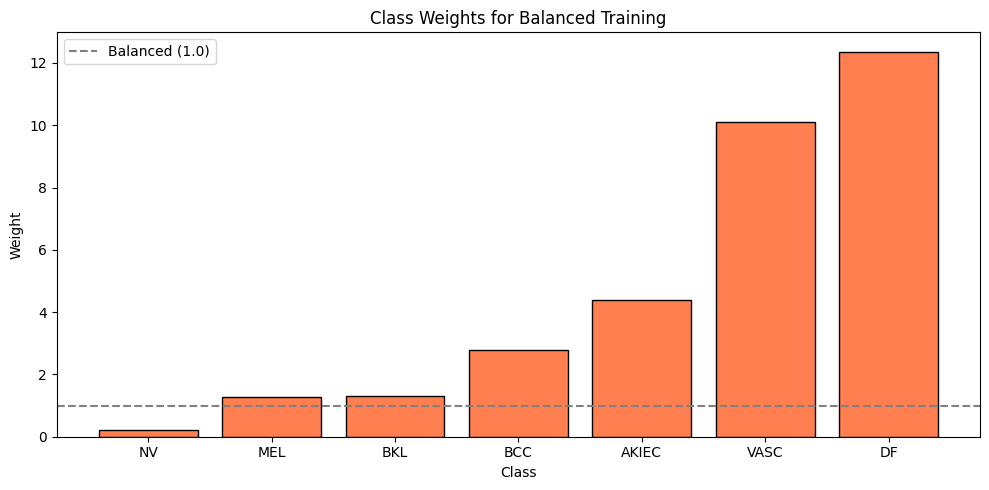

In [17]:
# Visualize weight distribution
fig, ax = plt.subplots(figsize=(10, 5))

classes = list(class_weights.keys())
weights = [class_weights[c] for c in classes]

bars = ax.bar(classes, weights, color="coral", edgecolor="black")
ax.axhline(y=1.0, color="gray", linestyle="--", label="Balanced (1.0)")
ax.set_xlabel("Class")
ax.set_ylabel("Weight")
ax.set_title("Class Weights for Balanced Training")
ax.legend()

plt.tight_layout()
plt.show()